<a href="https://colab.research.google.com/github/953625244013-cell/RFM-CLV-Personalized-Email/blob/main/Develop_CLV_RFM_Segmentation_and_Define_the_Personalized_Email_Workflow_day_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
data = {
    "CustomerID": [101, 102, 103, 104, 105, 106, 107, 108],
    "CustomerName": ["Priya", "Arun", "Kavi", "Dharshini",
                     "Nithya", "Selva", "Jeya", "Krishna"],
    "LastPurchaseDays": [10, 25, 45, 70, 15, 90, 35, 55],
    "Frequency": [12, 9, 4, 2, 10, 1, 7, 3],
    "Monetary": [12000, 8500, 3000, 1500, 9500, 800, 6000, 2500]
}

df = pd.DataFrame(data)

display(df)

,CustomerID,CustomerName,LastPurchaseDays,Frequency,Monetary
0,101,Priya,10,12,12000
1,102,Arun,25,9,8500
2,103,Kavi,45,4,3000
3,104,Dharshini,70,2,1500
4,105,Nithya,15,10,9500
5,106,Selva,90,1,800
6,107,Jeya,35,7,6000
7,108,Krishna,55,3,2500


In [3]:
df["R_Score"] = pd.qcut(
    df["LastPurchaseDays"].rank(method="first"),
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

df["F_Score"] = pd.qcut(
    df["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

df["M_Score"] = pd.qcut(
    df["Monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

df["RFM_Score"] = (
    df["R_Score"].astype(str) +
    df["F_Score"].astype(str) +
    df["M_Score"].astype(str)
)

display(df)

,CustomerID,CustomerName,LastPurchaseDays,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,101,Priya,10,12,12000,5,5,5,555
1,102,Arun,25,9,8500,4,4,4,444
2,103,Kavi,45,4,3000,3,3,3,333
3,104,Dharshini,70,2,1500,1,1,1,111
4,105,Nithya,15,10,9500,5,5,5,555
5,106,Selva,90,1,800,1,1,1,111
6,107,Jeya,35,7,6000,3,3,3,333
7,108,Krishna,55,3,2500,2,2,2,222


In [4]:
def get_segment(row):
    r = row["R_Score"]
    f = row["F_Score"]
    m = row["M_Score"]

    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"
    elif f >= 4 and m >= 3:
        return "Loyal Customers"
    elif r >= 3 and f >= 3:
        return "Potential Loyalists"
    elif r <= 2 and f >= 2:
        return "At Risk"
    elif r <= 2 and f <= 2:
        return "Lost Customers"
    else:
        return "Others"

df["Segment"] = df.apply(get_segment, axis=1)

display(df[[
    "CustomerID",
    "CustomerName",
    "RFM_Score",
    "Segment"
]])

,CustomerID,CustomerName,RFM_Score,Segment
0,101,Priya,555,Champions
1,102,Arun,444,Champions
2,103,Kavi,333,Potential Loyalists
3,104,Dharshini,111,Lost Customers
4,105,Nithya,555,Champions
5,106,Selva,111,Lost Customers
6,107,Jeya,333,Potential Loyalists
7,108,Krishna,222,At Risk


In [5]:
df["AveragePurchaseValue"] = df["Monetary"] / df["Frequency"]

df["PurchaseFrequency"] = df["Frequency"]

df["CustomerLifespan"] = 1

df["CLV"] = (
    df["AveragePurchaseValue"] *
    df["PurchaseFrequency"] *
    df["CustomerLifespan"]
)

df["CLV"] = df["CLV"].round(2)

display(df[[
    "CustomerID",
    "CustomerName",
    "Monetary",
    "Frequency",
    "CLV"
]])

,CustomerID,CustomerName,Monetary,Frequency,CLV
0,101,Priya,12000,12,12000.0
1,102,Arun,8500,9,8500.0
2,103,Kavi,3000,4,3000.0
3,104,Dharshini,1500,2,1500.0
4,105,Nithya,9500,10,9500.0
5,106,Selva,800,1,800.0
6,107,Jeya,6000,7,6000.0
7,108,Krishna,2500,3,2500.0


In [6]:
promotion_map = {
    "Champions": "20% discount",
    "Loyal Customers": "15% discount",
    "Potential Loyalists": "10% discount",
    "At Risk": "25% discount",
    "Lost Customers": "30% discount",
    "Others": "10% discount"
}

df["Promotion"] = df["Segment"].map(promotion_map)

display(df[[
    "CustomerName",
    "Segment",
    "CLV",
    "Promotion"
]])

,CustomerName,Segment,CLV,Promotion
0,Priya,Champions,12000.0,20% discount
1,Arun,Champions,8500.0,20% discount
2,Kavi,Potential Loyalists,3000.0,10% discount
3,Dharshini,Lost Customers,1500.0,30% discount
4,Nithya,Champions,9500.0,20% discount
5,Selva,Lost Customers,800.0,30% discount
6,Jeya,Potential Loyalists,6000.0,10% discount
7,Krishna,At Risk,2500.0,25% discount


In [7]:
def create_email(row):

    name = row["CustomerName"]
    segment = row["Segment"]
    promotion = row["Promotion"]

    if segment == "Champions":
        message = "Thank you for being one of our most valuable customers!"
    elif segment == "Loyal Customers":
        message = "We appreciate your continued loyalty!"
    elif segment == "Potential Loyalists":
        message = "You are becoming one of our valued customers!"
    elif segment == "At Risk":
        message = "We miss you! Come back and enjoy a special offer."
    elif segment == "Lost Customers":
        message = "We would love to welcome you back!"
    else:
        message = "We have a special offer for you!"

    email = f"""Subject: Special Offer Just for You

Hi {name},

{message}

Enjoy our {promotion} on your next purchase.

Shop now and enjoy your special offer!

Thank you,
Customer Support Team
"""

    return email

df["Personalized_Email"] = df.apply(create_email, axis=1)

print(df.loc[0, "Personalized_Email"])

Subject: Special Offer Just for You

Hi Priya,

Thank you for being one of our most valuable customers!

Enjoy our 20% discount on your next purchase.

Shop now and enjoy your special offer!

Thank you,
Customer Support Team



In [8]:
for index, row in df.iterrows():

    print("=" * 60)
    print(f"Customer: {row['CustomerName']}")
    print(f"Segment: {row['Segment']}")
    print(f"CLV: {row['CLV']}")
    print("=" * 60)

    print(row["Personalized_Email"])

Customer: Priya
Segment: Champions
CLV: 12000.0
Subject: Special Offer Just for You

Hi Priya,

Thank you for being one of our most valuable customers!

Enjoy our 20% discount on your next purchase.

Shop now and enjoy your special offer!

Thank you,
Customer Support Team

Customer: Arun
Segment: Champions
CLV: 8500.0
Subject: Special Offer Just for You

Hi Arun,

Thank you for being one of our most valuable customers!

Enjoy our 20% discount on your next purchase.

Shop now and enjoy your special offer!

Thank you,
Customer Support Team

Customer: Kavi
Segment: Potential Loyalists
CLV: 3000.0
Subject: Special Offer Just for You

Hi Kavi,

You are becoming one of our valued customers!

Enjoy our 10% discount on your next purchase.

Shop now and enjoy your special offer!

Thank you,
Customer Support Team

Customer: Dharshini
Segment: Lost Customers
CLV: 1500.0
Subject: Special Offer Just for You

Hi Dharshini,

We would love to welcome you back!

Enjoy our 30% discount on your next purc

In [9]:
final_df = df[[
    "CustomerID",
    "CustomerName",
    "R_Score",
    "F_Score",
    "M_Score",
    "RFM_Score",
    "Segment",
    "CLV",
    "Promotion"
]]

display(final_df)

,CustomerID,CustomerName,R_Score,F_Score,M_Score,RFM_Score,Segment,CLV,Promotion
0,101,Priya,5,5,5,555,Champions,12000.0,20% discount
1,102,Arun,4,4,4,444,Champions,8500.0,20% discount
2,103,Kavi,3,3,3,333,Potential Loyalists,3000.0,10% discount
3,104,Dharshini,1,1,1,111,Lost Customers,1500.0,30% discount
4,105,Nithya,5,5,5,555,Champions,9500.0,20% discount
5,106,Selva,1,1,1,111,Lost Customers,800.0,30% discount
6,107,Jeya,3,3,3,333,Potential Loyalists,6000.0,10% discount
7,108,Krishna,2,2,2,222,At Risk,2500.0,25% discount


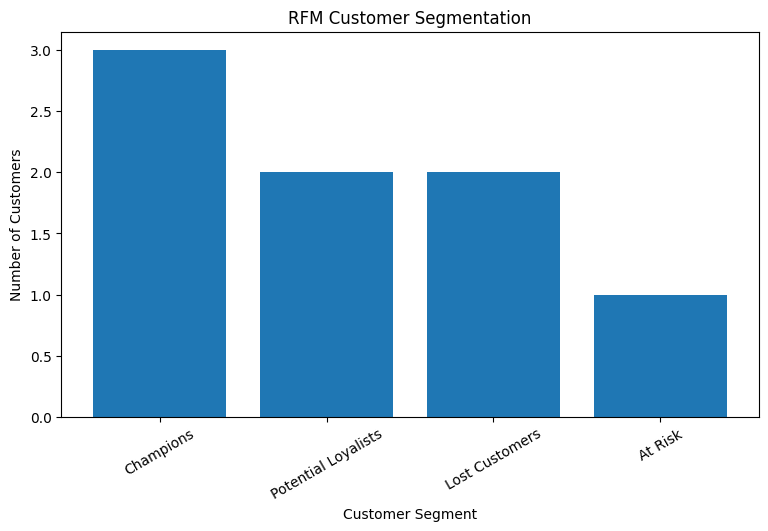

In [10]:
import matplotlib.pyplot as plt

segment_counts = df["Segment"].value_counts()

plt.figure(figsize=(9, 5))
plt.bar(segment_counts.index, segment_counts.values)

plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.title("RFM Customer Segmentation")

plt.xticks(rotation=30)
plt.show()

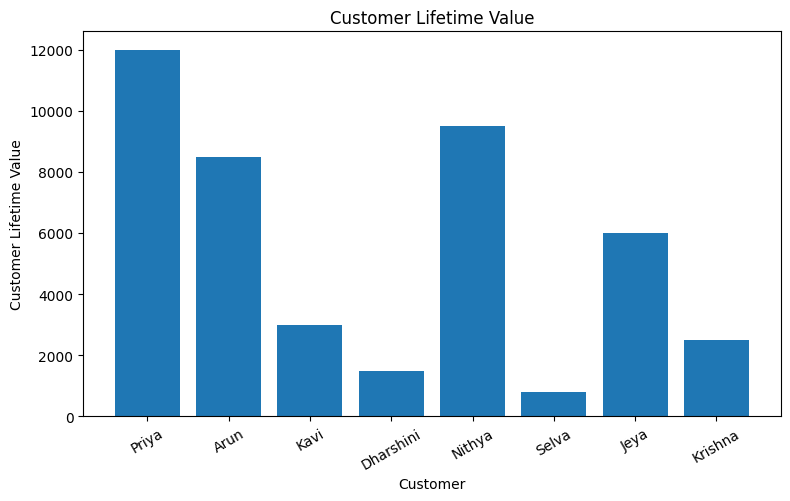

In [11]:
plt.figure(figsize=(9, 5))

plt.bar(
    df["CustomerName"],
    df["CLV"]
)

plt.xlabel("Customer")
plt.ylabel("Customer Lifetime Value")
plt.title("Customer Lifetime Value")

plt.xticks(rotation=30)
plt.show()

In [12]:
workflow = [
    "1. Collect customer transaction data",
    "2. Calculate Recency, Frequency and Monetary values",
    "3. Generate RFM scores",
    "4. Assign customers to RFM segments",
    "5. Calculate Customer Lifetime Value (CLV)",
    "6. Assign segment-specific promotional offers",
    "7. Generate personalized email content",
    "8. Display and evaluate generated emails"
]

print("PERSONALIZED EMAIL WORKFLOW")
print("=" * 40)

for step in workflow:
    print(step)

PERSONALIZED EMAIL WORKFLOW
1. Collect customer transaction data
2. Calculate Recency, Frequency and Monetary values
3. Generate RFM scores
4. Assign customers to RFM segments
5. Calculate Customer Lifetime Value (CLV)
6. Assign segment-specific promotional offers
7. Generate personalized email content
8. Display and evaluate generated emails


In [13]:
df.to_csv(
    "CLV_RFM_Personalized_Email_Workflow.csv",
    index=False
)

print("Results saved successfully!")
print("File: CLV_RFM_Personalized_Email_Workflow.csv")

Results saved successfully!
File: CLV_RFM_Personalized_Email_Workflow.csv


In [14]:
print("=" * 60)
print("CLV/RFM SEGMENTATION AND PERSONALIZED EMAIL WORKFLOW")
print("=" * 60)

print("\nCustomers analyzed:", len(df))
print("Segments identified:", df["Segment"].nunique())
print("Personalized emails generated:", len(df))

print("\nWorkflow completed successfully!")

CLV/RFM SEGMENTATION AND PERSONALIZED EMAIL WORKFLOW

Customers analyzed: 8
Segments identified: 4
Personalized emails generated: 8

Workflow completed successfully!


In [15]:
segment_summary = df.groupby("Segment").agg(
    Customer_Count=("CustomerID", "count"),
    Average_CLV=("CLV", "mean"),
    Average_Monetary=("Monetary", "mean"),
    Average_Frequency=("Frequency", "mean")
).round(2)

display(segment_summary)

,Customer_Count,Average_CLV,Average_Monetary,Average_Frequency
Segment,,,,
At Risk,1,2500.0,2500.0,3.00
Champions,3,10000.0,10000.0,10.33
Lost Customers,2,1150.0,1150.0,1.50
Potential Loyalists,2,4500.0,4500.0,5.50


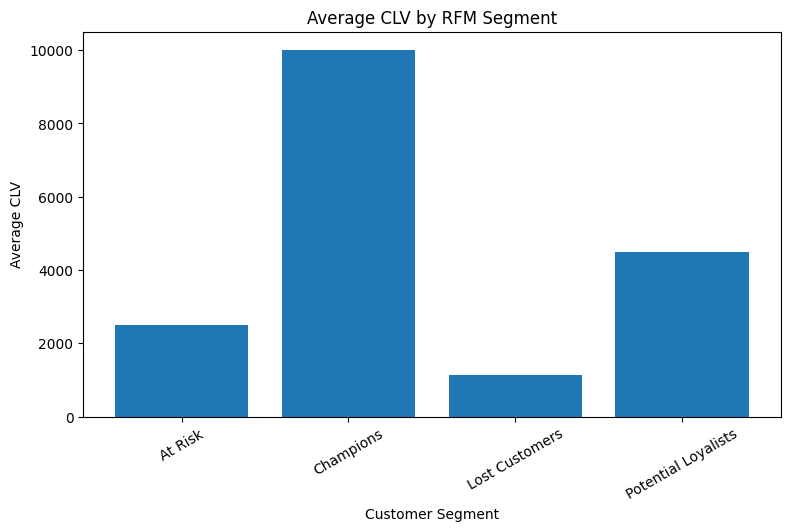

In [16]:
plt.figure(figsize=(9, 5))

segment_clv = df.groupby("Segment")["CLV"].mean()

plt.bar(segment_clv.index, segment_clv.values)

plt.xlabel("Customer Segment")
plt.ylabel("Average CLV")
plt.title("Average CLV by RFM Segment")

plt.xticks(rotation=30)
plt.show()

In [17]:
segment_summary = df.groupby("Segment").agg(
    Customer_Count=("CustomerID", "count"),
    Average_CLV=("CLV", "mean"),
    Average_Monetary=("Monetary", "mean"),
    Average_Frequency=("Frequency", "mean")
).round(2)

display(segment_summary)

,Customer_Count,Average_CLV,Average_Monetary,Average_Frequency
Segment,,,,
At Risk,1,2500.0,2500.0,3.00
Champions,3,10000.0,10000.0,10.33
Lost Customers,2,1150.0,1150.0,1.50
Potential Loyalists,2,4500.0,4500.0,5.50


In [18]:
workflow = [
    "1. Collect customer transaction data",
    "2. Calculate RFM values",
    "3. Generate RFM scores",
    "4. Segment customers",
    "5. Calculate CLV",
    "6. Assign segment-specific offers",
    "7. Generate personalized emails",
    "8. Analyze customer segments and CLV"
]

print("PERSONALIZED EMAIL WORKFLOW")
print("=" * 40)

for step in workflow:
    print(step)

PERSONALIZED EMAIL WORKFLOW
1. Collect customer transaction data
2. Calculate RFM values
3. Generate RFM scores
4. Segment customers
5. Calculate CLV
6. Assign segment-specific offers
7. Generate personalized emails
8. Analyze customer segments and CLV


In [19]:
for index, row in df.iterrows():
    print("=" * 60)
    print("Customer:", row["CustomerName"])
    print("Segment:", row["Segment"])
    print("CLV:", row["CLV"])
    print("-" * 60)
    print(row["Personalized_Email"])

Customer: Priya
Segment: Champions
CLV: 12000.0
------------------------------------------------------------
Subject: Special Offer Just for You

Hi Priya,

Thank you for being one of our most valuable customers!

Enjoy our 20% discount on your next purchase.

Shop now and enjoy your special offer!

Thank you,
Customer Support Team

Customer: Arun
Segment: Champions
CLV: 8500.0
------------------------------------------------------------
Subject: Special Offer Just for You

Hi Arun,

Thank you for being one of our most valuable customers!

Enjoy our 20% discount on your next purchase.

Shop now and enjoy your special offer!

Thank you,
Customer Support Team

Customer: Kavi
Segment: Potential Loyalists
CLV: 3000.0
------------------------------------------------------------
Subject: Special Offer Just for You

Hi Kavi,

You are becoming one of our valued customers!

Enjoy our 10% discount on your next purchase.

Shop now and enjoy your special offer!

Thank you,
Customer Support Team

C

In [20]:
df.to_csv(
    "CLV_RFM_Personalized_Email_Workflow.csv",
    index=False
)

print("Final results saved successfully!")

Final results saved successfully!


In [21]:
print("=" * 55)
print("CLV/RFM SEGMENTATION COMPLETED")
print("=" * 55)

print("Customers analyzed:", len(df))
print("Segments identified:", df["Segment"].nunique())
print("Personalized emails generated:", len(df))

print("\nRFM segmentation, CLV calculation,")
print("and personalized email workflow completed successfully.")

CLV/RFM SEGMENTATION COMPLETED
Customers analyzed: 8
Segments identified: 4
Personalized emails generated: 8

RFM segmentation, CLV calculation,
and personalized email workflow completed successfully.


In [22]:
from google.colab import files

files.download("CLV_RFM_Personalized_Email_Workflow.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
final_report = df[
    [
        "CustomerID",
        "CustomerName",
        "RFM_Score",
        "Segment",
        "CLV",
        "Promotion"
    ]
]

print("FINAL CUSTOMER SEGMENT REPORT")
print("=" * 50)

display(final_report)

FINAL CUSTOMER SEGMENT REPORT


,CustomerID,CustomerName,RFM_Score,Segment,CLV,Promotion
0,101,Priya,555,Champions,12000.0,20% discount
1,102,Arun,444,Champions,8500.0,20% discount
2,103,Kavi,333,Potential Loyalists,3000.0,10% discount
3,104,Dharshini,111,Lost Customers,1500.0,30% discount
4,105,Nithya,555,Champions,9500.0,20% discount
5,106,Selva,111,Lost Customers,800.0,30% discount
6,107,Jeya,333,Potential Loyalists,6000.0,10% discount
7,108,Krishna,222,At Risk,2500.0,25% discount


In [24]:
segment_count = df["Segment"].value_counts().reset_index()

segment_count.columns = [
    "Segment",
    "Customer Count"
]

print("SEGMENT-WISE CUSTOMER COUNT")
print("=" * 40)

display(segment_count)

SEGMENT-WISE CUSTOMER COUNT


,Segment,Customer Count
0,Champions,3
1,Potential Loyalists,2
2,Lost Customers,2
3,At Risk,1


In [25]:
print("=" * 60)
print("PERSONALIZED EMAIL WORKFLOW - SUMMARY")
print("=" * 60)

print("\n1. Customer data collected")
print("2. RFM values calculated")
print("3. RFM scores generated")
print("4. Customers segmented")
print("5. CLV calculated")
print("6. Segment-specific offers assigned")
print("7. Personalized emails generated")
print("8. Customer segments and CLV analyzed")
print("9. Results saved for further use")

print("\nSTATUS: WORKFLOW COMPLETED SUCCESSFULLY")

PERSONALIZED EMAIL WORKFLOW - SUMMARY

1. Customer data collected
2. RFM values calculated
3. RFM scores generated
4. Customers segmented
5. CLV calculated
6. Segment-specific offers assigned
7. Personalized emails generated
8. Customer segments and CLV analyzed
9. Results saved for further use

STATUS: WORKFLOW COMPLETED SUCCESSFULLY


In [26]:
output = df[
    [
        "CustomerID",
        "CustomerName",
        "RFM_Score",
        "Segment",
        "CLV",
        "Promotion"
    ]
].copy()

print("FINAL OUTPUT")
print("=" * 50)

display(output)

FINAL OUTPUT


,CustomerID,CustomerName,RFM_Score,Segment,CLV,Promotion
0,101,Priya,555,Champions,12000.0,20% discount
1,102,Arun,444,Champions,8500.0,20% discount
2,103,Kavi,333,Potential Loyalists,3000.0,10% discount
3,104,Dharshini,111,Lost Customers,1500.0,30% discount
4,105,Nithya,555,Champions,9500.0,20% discount
5,106,Selva,111,Lost Customers,800.0,30% discount
6,107,Jeya,333,Potential Loyalists,6000.0,10% discount
7,108,Krishna,222,At Risk,2500.0,25% discount


In [27]:
print("=" * 55)
print("CONCLUSION")
print("=" * 55)

print(
    "CLV and RFM analysis was used to understand customer value "
    "and purchasing behavior."
)

print(
    "Customers were divided into meaningful RFM segments and "
    "segment-specific promotional offers were assigned."
)

print(
    "A personalized email workflow was then defined to generate "
    "relevant promotional emails for each customer."
)

print("\nCLV/RFM segmentation and personalized email workflow completed.")

CONCLUSION
CLV and RFM analysis was used to understand customer value and purchasing behavior.
Customers were divided into meaningful RFM segments and segment-specific promotional offers were assigned.
A personalized email workflow was then defined to generate relevant promotional emails for each customer.

CLV/RFM segmentation and personalized email workflow completed.


In [28]:
print("=" * 60)
print("PROJECT TASK COMPLETED")
print("=" * 60)

print("Task: Develop CLV/RFM segmentation and define")
print("the personalized email workflow.")

print("\nCompleted Components:")
print("✓ RFM Analysis")
print("✓ Customer Segmentation")
print("✓ CLV Calculation")
print("✓ Promotional Offer Assignment")
print("✓ Personalized Email Generation")
print("✓ Email Workflow Definition")
print("✓ Segment and CLV Visualization")
print("✓ Final Results Export")

print("\nStatus: COMPLETED SUCCESSFULLY")

PROJECT TASK COMPLETED
Task: Develop CLV/RFM segmentation and define
the personalized email workflow.

Completed Components:
✓ RFM Analysis
✓ Customer Segmentation
✓ CLV Calculation
✓ Promotional Offer Assignment
✓ Personalized Email Generation
✓ Email Workflow Definition
✓ Segment and CLV Visualization
✓ Final Results Export

Status: COMPLETED SUCCESSFULLY
